# 1. Setup do Ambiente

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 130

# 2. Carregamento dos Dados

In [2]:
date_fns = pd.read_csv("../logs/method-reconstruction-experiment/date-fns/structured/result.csv")
directus  = pd.read_csv("../logs/method-reconstruction-experiment/directus/structured/result.csv")

df = pd.concat([date_fns, directus], ignore_index=True)

# 3. Limpeza e Tratamento de Dados

In [3]:
for col in ["isTestSuiteSuccessful", "isModelResultCompilable"]:
    df[col] = df[col].map({"true": True, "false": False, True: True, False: False})

df["passRate"] = df["testSuitePassedTestCaseCount"] / df["testSuiteTotalTestCaseCount"]

df["contextType"] = df["experimentTitle"]
df["model"]       = df["modelName"]
df["permIdx"]     = df["experimentIndex"]
df["totalPerms"]  = df["experimentSize"]

df["subsetSize"]    = df["relevantTestCaseCount"]
df["isFullContext"] = df["contextType"] != "no-relevant-test-case"

print(df.shape)
df.head(3)

(88, 30)


,repositoryName,methodName,methodResolvedFilePath,experimentTitle,experimentDescription,experimentContextItemCount,experimentIndex,experimentSize,experimentContextSlugs,modelSystemPrompt,...,testSuiteTotalTestCaseCount,testSuitePassedTestCaseCount,testSuiteFailedTestCaseCount,passRate,contextType,model,permIdx,totalPerms,subsetSize,isFullContext
0,date-fns,areIntervalsOverlapping,/home/guilhermebkel/Personal/tcc-context-impor...,all-relevant-test-case,areIntervalsOverlapping > all-relevant-test-ca...,5,1,1,relevant-test-case,"""# SYSTEM PROMPT: METHOD RECONSTRUCTOR\n\n## 1...",...,19,19,0,1.0,all-relevant-test-case,gemini-2.5-flash,1,1,5,True
1,date-fns,areIntervalsOverlapping,/home/guilhermebkel/Personal/tcc-context-impor...,permuted-relevant-test-case,areIntervalsOverlapping > permuted-relevant-te...,5,1,5,relevant-test-case,"""# SYSTEM PROMPT: METHOD RECONSTRUCTOR\n\n## 1...",...,19,19,0,1.0,permuted-relevant-test-case,gemini-2.5-flash,1,5,5,True
2,date-fns,areIntervalsOverlapping,/home/guilhermebkel/Personal/tcc-context-impor...,permuted-relevant-test-case,areIntervalsOverlapping > permuted-relevant-te...,4,2,5,relevant-test-case,"""# SYSTEM PROMPT: METHOD RECONSTRUCTOR\n\n## 1...",...,19,19,0,1.0,permuted-relevant-test-case,gemini-2.5-flash,2,5,4,True


In [4]:
print("Repositórios:", df["repositoryName"].value_counts().to_dict())
print("Métodos únicos:", df["methodName"].nunique())
print("Modelos:", df["model"].unique())
print("Tipos de contexto:", df["contextType"].unique())
print("Linhas por (modelo, contextType):")
print(df.groupby(["model", "contextType"]).size().to_string())
print("\nTaxa global de sucesso:", round(df["isTestSuiteSuccessful"].mean(), 4))
print("Taxa global de compilabilidade:", round(df["isModelResultCompilable"].mean(), 4))

Repositórios: {'date-fns': 88}
Métodos únicos: 3
Modelos: ['gemini-2.5-flash' 'gemini-2.5-pro' 'gemini-3.0-flash' 'gemini-3.0-pro']
Tipos de contexto: ['all-relevant-test-case' 'permuted-relevant-test-case'
 'no-relevant-test-case']
Linhas por (modelo, contextType):
model             contextType                
gemini-2.5-flash  all-relevant-test-case          3
                  no-relevant-test-case           3
                  permuted-relevant-test-case    18
gemini-2.5-pro    all-relevant-test-case          3
                  no-relevant-test-case           3
                  permuted-relevant-test-case    18
gemini-3.0-flash  all-relevant-test-case          3
                  no-relevant-test-case           3
                  permuted-relevant-test-case    18
gemini-3.0-pro    all-relevant-test-case          2
                  no-relevant-test-case           2
                  permuted-relevant-test-case    12

Taxa global de sucesso: 0.3636
Taxa global de compilabilidade:

# 4. Análise Exploratória de Dados

## Análise em Código

### Taxa de sucesso por tipo de contexto e modelo

TypeError: no numeric data to plot

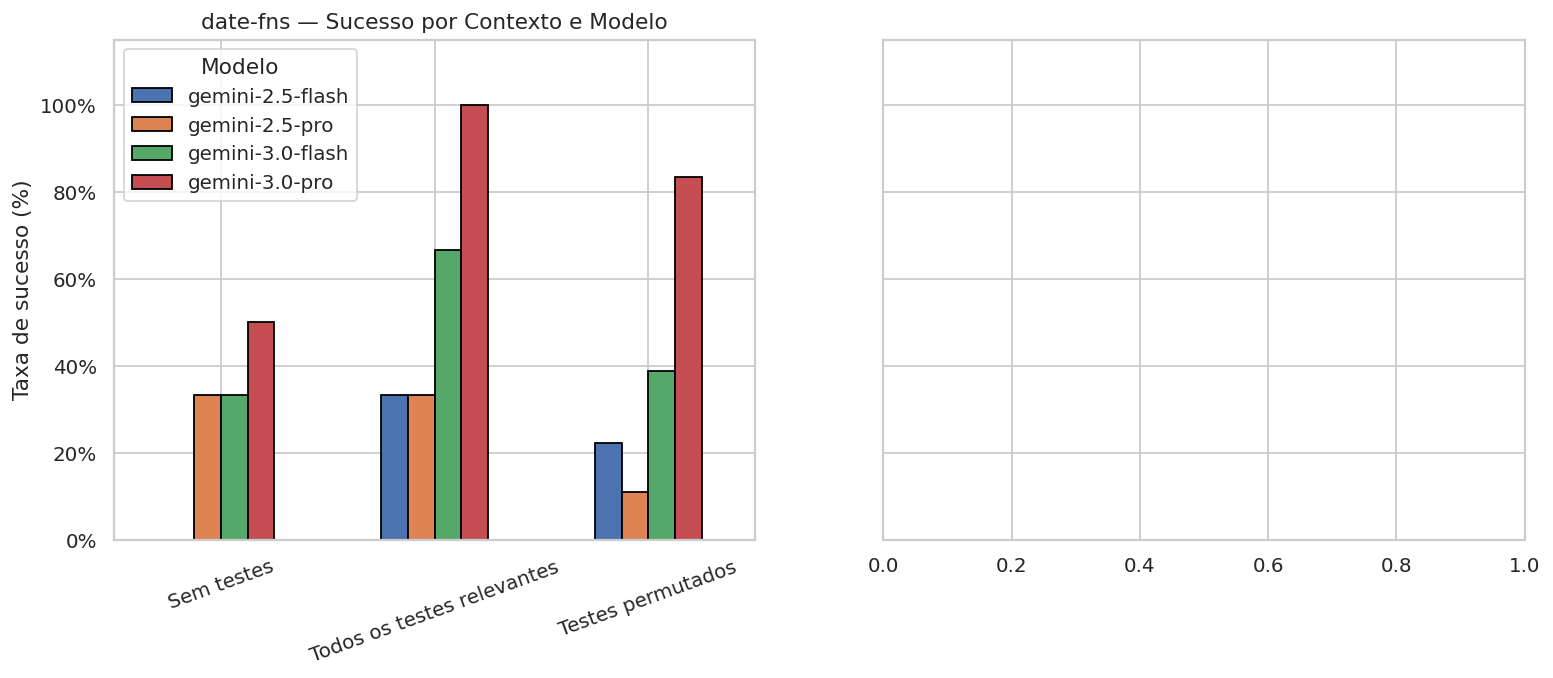

In [5]:
CONTEXT_ORDER = ["no-relevant-test-case", "all-relevant-test-case", "permuted-relevant-test-case"]
CONTEXT_LABELS = {
    "no-relevant-test-case":       "Sem testes",
    "all-relevant-test-case":      "Todos os testes relevantes",
    "permuted-relevant-test-case": "Testes permutados",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, repo in zip(axes, ["date-fns", "directus"]):
    subset = df[df["repositoryName"] == repo]
    rates = (
        subset.groupby(["contextType", "model"])["isTestSuiteSuccessful"]
        .mean()
        .unstack("model")
        .reindex([c for c in CONTEXT_ORDER if c in subset["contextType"].unique()])
    )
    rates.index = [CONTEXT_LABELS.get(i, i) for i in rates.index]
    rates = rates * 100
    rates.plot(kind="bar", ax=ax, edgecolor="black")
    ax.set_title(f"{repo} — Sucesso por Contexto e Modelo")
    ax.set_ylabel("Taxa de sucesso (%)")
    ax.set_ylim(0, 115)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.tick_params(axis="x", rotation=20)
    ax.legend(title="Modelo")

plt.tight_layout()
plt.savefig("success_by_context_model.png", bbox_inches="tight")
plt.show()

### Sucesso por método, contexto e modelo (heatmap)

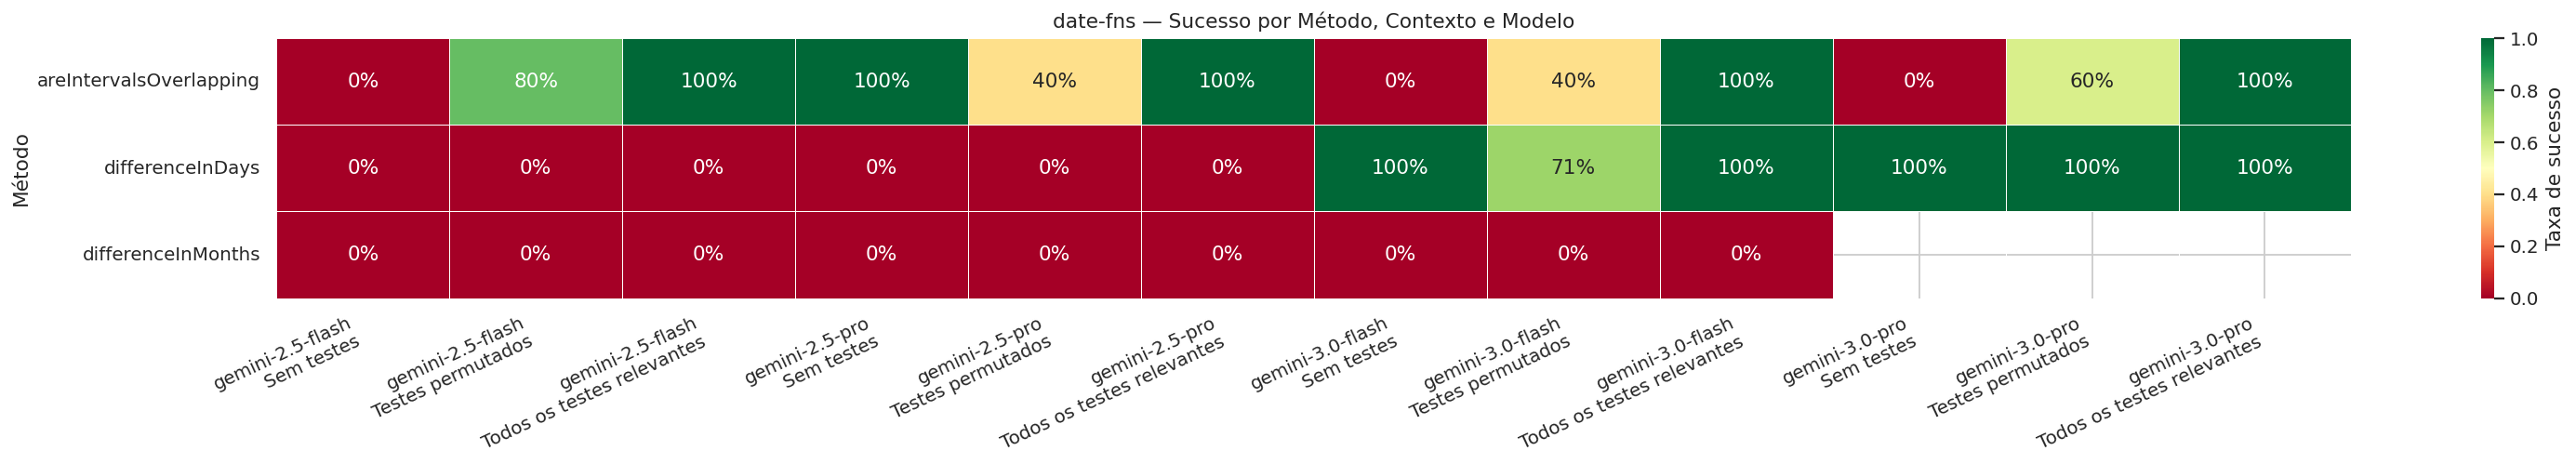

/home/guilhermebkel/Personal/tcc-context-importance-in-llm-development-tasks/research/.venv/lib/python3.13/site-packages/seaborn/matrix.py:309: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))
/home/guilhermebkel/Personal/tcc-context-importance-in-llm-development-tasks/research/.venv/lib/python3.13/site-packages/seaborn/matrix.py:309: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))


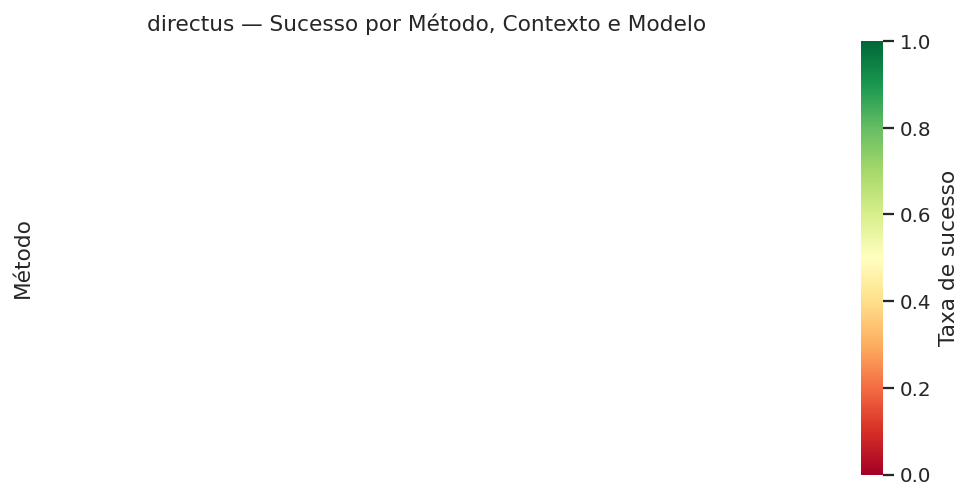

In [6]:
for repo in ["date-fns", "directus"]:
    pivot = (
        df[df["repositoryName"] == repo]
        .groupby(["methodName", "contextType", "model"])["isTestSuiteSuccessful"]
        .mean()
        .reset_index()
        .assign(col=lambda d: d["model"] + "\n" + d["contextType"].map(CONTEXT_LABELS).fillna(d["contextType"]))
        .pivot(index="methodName", columns="col", values="isTestSuiteSuccessful")
        .fillna(np.nan)
    )
    plt.figure(figsize=(max(8, len(pivot.columns) * 2), max(4, len(pivot) * 0.6)))
    sns.heatmap(pivot, annot=True, fmt=".0%", cmap="RdYlGn",
                vmin=0, vmax=1, linewidths=0.5,
                cbar_kws={"label": "Taxa de sucesso"})
    plt.title(f"{repo} — Sucesso por Método, Contexto e Modelo")
    plt.xlabel("")
    plt.ylabel("Método")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.savefig(f"heatmap_method_{repo}.png", bbox_inches="tight")
    plt.show()

### Variância entre permutações (mesmos testes, ordem diferente)

In [ ]:
permuted_only = df[df["contextType"] == "permuted-relevant-test-case"].copy()

if permuted_only.empty:
    print("Nenhuma execução com 'permuted-relevant-test-case' encontrada nos dados ainda.")
    print("Esta análise ficará disponível quando esses experimentos forem executados.")
else:
    variance = (
        permuted_only.groupby(["repositoryName", "methodName", "model"])["passRate"]
        .agg(["mean", "std", "count"])
        .reset_index()
        .rename(columns={"std": "permutationStd"})
        .sort_values("permutationStd", ascending=False)
    )
    print("Métodos mais sensíveis à ordem dos testes:")
    print(variance.to_string(index=False))

In [ ]:
if permuted_only.empty:
    print("Sem dados de permutação para plotar.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, repo in zip(axes, ["date-fns", "directus"]):
        data = permuted_only[permuted_only["repositoryName"] == repo]
        if data.empty:
            ax.text(0.5, 0.5, "Sem dados", ha="center", va="center", transform=ax.transAxes)
            ax.set_title(repo)
            continue
        for model, grp in data.groupby("model"):
            grp_sorted = grp.sort_values("permIdx")
            ax.plot(grp_sorted["permIdx"], grp_sorted["passRate"], marker="o", label=model, alpha=0.7)
        ax.set_title(f"{repo} — Pass Rate por Permutação")
        ax.set_xlabel("Índice da permutação")
        ax.set_ylabel("Pass Rate")
        ax.set_ylim(-0.05, 1.05)
        ax.legend(title="Modelo")

    plt.suptitle("Sensibilidade à Ordem dos Testes")
    plt.tight_layout()
    plt.savefig("permutation_sensitivity.png", bbox_inches="tight")
    plt.show()

### Nº de testes relevantes × taxa de sucesso (cross-método)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, repo in zip(axes, ["date-fns", "directus"]):
    subset = df[(df["repositoryName"] == repo) & (df["contextType"] == "all-relevant-test-case")]
    for model, grp in subset.groupby("model"):
        agg = grp.groupby("subsetSize")["isTestSuiteSuccessful"].mean() * 100
        ax.scatter(agg.index, agg.values, label=model, s=80, alpha=0.8)
    ax.set_title(f"{repo}")
    ax.set_xlabel("Nº de testes relevantes do método")
    ax.set_ylabel("Taxa de sucesso (%)")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.legend(title="Modelo")

plt.suptitle("Testes Relevantes Disponíveis × Taxa de Sucesso (todos os testes fornecidos)")
plt.tight_layout()
plt.savefig("relevant_count_vs_success.png", bbox_inches="tight")
plt.show()

### Compilabilidade vs. sucesso por tamanho do subconjunto

In [ ]:
compilable_vs_pass = (
    df.groupby(["repositoryName", "subsetSize"])
    .agg(
        compilable=("isModelResultCompilable", "mean"),
        success=("isTestSuiteSuccessful", "mean")
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, repo in zip(axes, ["date-fns", "directus"]):
    d = compilable_vs_pass[compilable_vs_pass["repositoryName"] == repo]
    ax.plot(d["subsetSize"], d["compilable"] * 100, marker="s", label="Compilável", linestyle="--")
    ax.plot(d["subsetSize"], d["success"] * 100, marker="o", label="Todos os testes passam")
    ax.set_title(f"{repo}")
    ax.set_xlabel("Nº de testes como contexto")
    ax.set_ylabel("Taxa (%)")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.legend()

plt.suptitle("Compilabilidade vs. Sucesso por Tamanho do Subconjunto")
plt.tight_layout()
plt.savefig("compilable_vs_success.png", bbox_inches="tight")
plt.show()

## Análise em Linguagem Natural

### Setup do Agente

In [ ]:
import os
from dotenv import load_dotenv
from google import genai
from pandasai import Agent
from pandasai.llm.base import LLM

load_dotenv("../.env")

class GoogleGenAILLM(LLM):
    def __init__(self, model: str, api_key: str):
        self.model = model
        self._client = genai.Client(api_key=api_key)

    def call(self, instruction, context=None):
        self.last_prompt = instruction.to_string()
        response = self._client.models.generate_content(
            model=self.model,
            contents=self.last_prompt,
        )
        return response.text

    @property
    def type(self) -> str:
        return "google-genai"

llm = GoogleGenAILLM(model="gemini-3-flash-preview", api_key=os.environ["GOOGLE_GENERATIVE_AI_API_KEY"])
agent = Agent([df], config={"llm": llm, "verbose": False, "custom_whitelisted_dependencies": ["os"], "open_charts": False})

In [ ]:
from IPython.display import display, Markdown, Image
import os

def show_agent_result(result):
    if isinstance(result, str) and os.path.isfile(result):
        display(Image(filename=result))
    elif isinstance(result, str):
        display(Markdown(result))
    else:
        display(result)


### Perguntas para o Agente

In [ ]:
questions = [
    # "Fornecer testes relevantes aumenta significativamente o passRate em relação a não fornecer nenhum teste?",
    # "Entre os métodos com testes permutados, qual apresentou maior variação de passRate entre as permutações?",
    # "A ordem dos testes no prompt afeta o resultado mais no date-fns ou no directus?",
    # "Qual modelo foi mais consistente entre os repositórios date-fns e directus?",
    # "Existe algum tipo de contexto onde os modelos divergem muito entre si?",
    # "Quais métodos foram reconstruídos com sucesso em todos os contextos testados?",
    # "Quais métodos nunca foram reconstruídos com sucesso, independente do contexto ou modelo?",
    # "Resuma os principais achados do experimento em tópicos.",
    # "Existe algum padrão claro que indique quando o contexto de testes ajuda e quando não ajuda?",
]

for question in questions:
    display(Markdown(f"---\n### {question}"))
    show_agent_result(agent.chat(question))